<div style="background:linear-gradient(135deg,#1a3a5c,#2980b9);border-radius:12px;padding:30px;text-align:center;margin-bottom:20px;">
  <h1 style="color:white;margin:0;font-size:32px;letter-spacing:1px;">Omar Gamal ElKady</h1>
  <p style="color:#cce4ff;margin:8px 0 4px;font-size:16px;">ITI Intake 46 &mdash; Track AI</p>
  <hr style="border:1px solid rgba(255,255,255,0.3);width:50%;margin:14px auto;">
  <h2 style="color:white;margin:0;font-size:24px;font-weight:400;">CIFAR-10: Transfer Learning</h2>
</div>

<div style="background:#f8faff;border:1px solid #d0e4f7;border-radius:10px;padding:20px;margin-bottom:15px;">
  <h3 style="color:#2e6da4;margin:0 0 12px;text-align:center;">Techniques Overview</h3>
  <table border="0" cellpadding="10" cellspacing="0" style="border-collapse:collapse;width:100%;font-size:14px;">
    <thead>
      <tr style="background:#2e6da4;color:white;">
        <th style="border-radius:6px 0 0 0;padding:10px;">#</th>
        <th>Technique</th><th>Model</th><th style="border-radius:0 6px 0 0;">Description</th>
      </tr>
    </thead>
    <tbody>
      <tr style="background:#eaf4ff;"><td style="text-align:center;font-weight:bold;">1</td><td>Feature Extraction (Offline Learning)</td><td style="text-align:center;">VGG16</td><td>Freeze entire base, extract features once, train dense head</td></tr>
      <tr style="background:#f8faff;"><td style="text-align:center;font-weight:bold;">2</td><td>Feature Extraction (End-to-End / Online Learning)</td><td style="text-align:center;">VGG16</td><td>Freeze base, train end-to-end with augmentation</td></tr>
      <tr style="background:#eaf4ff;"><td style="text-align:center;font-weight:bold;">3</td><td>Partial Fine-tuning</td><td style="text-align:center;">VGG16</td><td>Unfreeze top 2 conv blocks, retrain at low LR</td></tr>
      <tr style="background:#f8faff;"><td style="text-align:center;font-weight:bold;">4</td><td>Full Fine-tuning</td><td style="text-align:center;">VGG16</td><td>Unfreeze all layers, train at very low LR</td></tr>
    </tbody>
  </table>
</div>

<div style="background:linear-gradient(135deg,#1a3a5c,#2e6da4);border-radius:10px;padding:15px 24px;margin:20px 0 10px;"><h2 style="color:white;margin:0;font-size:20px;">&#9679; 0. Imports</h2></div>

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator

<div style="background:linear-gradient(135deg,#1a3a5c,#2e6da4);border-radius:10px;padding:15px 24px;margin:20px 0 10px;"><h2 style="color:white;margin:0;font-size:20px;">&#9679; 1. Utility Functions</h2></div>

In [3]:
def plot_history(history, title="Training Curves"):
    """Plot accuracy and loss curves for a single model."""
    epochs = range(1, len(history.history["accuracy"]) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(epochs, history.history["accuracy"],     label="Train")
    ax1.plot(epochs, history.history["val_accuracy"], label="Val")
    ax1.set_title(f"{title} — Accuracy")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Accuracy")
    ax1.legend(); ax1.grid(True)

    ax2.plot(epochs, history.history["loss"],     label="Train")
    ax2.plot(epochs, history.history["val_loss"], label="Val")
    ax2.set_title(f"{title} — Loss")
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Loss")
    ax2.legend(); ax2.grid(True)

    plt.suptitle(title, fontsize=13)
    plt.tight_layout(); plt.show()


def plot_comparison(histories, names):
    """Plot accuracy and loss side-by-side for multiple models."""
    n = len(histories)
    fig, axes = plt.subplots(n, 2, figsize=(14, 5 * n))
    if n == 1:
        axes = [axes]

    for i, (history, name) in enumerate(zip(histories, names)):
        epochs = range(1, len(history.history["accuracy"]) + 1)

        axes[i][0].plot(epochs, history.history["accuracy"],     label="Train")
        axes[i][0].plot(epochs, history.history["val_accuracy"], label="Val")
        axes[i][0].set_title(f"{name} — Accuracy")
        axes[i][0].set_xlabel("Epoch"); axes[i][0].set_ylabel("Accuracy")
        axes[i][0].legend(); axes[i][0].grid(True)

        axes[i][1].plot(epochs, history.history["loss"],     label="Train")
        axes[i][1].plot(epochs, history.history["val_loss"], label="Val")
        axes[i][1].set_title(f"{name} — Loss")
        axes[i][1].set_xlabel("Epoch"); axes[i][1].set_ylabel("Loss")
        axes[i][1].legend(); axes[i][1].grid(True)

    plt.suptitle("Model Comparison", fontsize=15, fontweight="bold")
    plt.tight_layout(); plt.show()


def print_summary(histories, names):
    """Print a summary table of final train/val accuracy and the gap."""
    col = 18
    print("=" * (28 + col * len(names)))
    print(f"{'Metric':<28}" + "".join(f"{n:>{col}}" for n in names))
    print("=" * (28 + col * len(names)))
    rows = {
        "Train Accuracy":  [h.history["accuracy"][-1]     for h in histories],
        "Val   Accuracy":  [h.history["val_accuracy"][-1] for h in histories],
        "Gap (Train-Val)": [h.history["accuracy"][-1] - h.history["val_accuracy"][-1] for h in histories],
    }
    for label, values in rows.items():
        print(f"{label:<28}" + "".join(f"{v:>{col}.4f}" for v in values))
    print("=" * (28 + col * len(names)))

<div style="background:linear-gradient(135deg,#1a3a5c,#2e6da4);border-radius:10px;padding:18px 24px;margin:20px 0 10px;">
  <h2 style="color:white;margin:0;font-size:20px;">&#9679; 2. Load &amp; Preprocess Data</h2>
</div>
<div style="background:#f8faff;border:1px solid #d0e4f7;border-radius:8px;padding:14px 18px;margin:8px 0;">
  <p style="margin:0;color:#2c3e50;line-height:1.7;">We load the full CIFAR-10 dataset and <strong>resize images from 32&times;32 &rarr; 96&times;96</strong> so the pretrained conv filters (designed for ImageNet 224&times;224) have enough spatial resolution to extract meaningful features.</p>
</div>

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Using 20000 training samples out of 50,000
Raw train shape: (20000, 32, 32, 3)  |  Test shape: (10000, 32, 32, 3)


I0000 00:00:1773168962.152591      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Resized train: (20000, 96, 96, 3)  |  Resized test: (10000, 96, 96, 3)


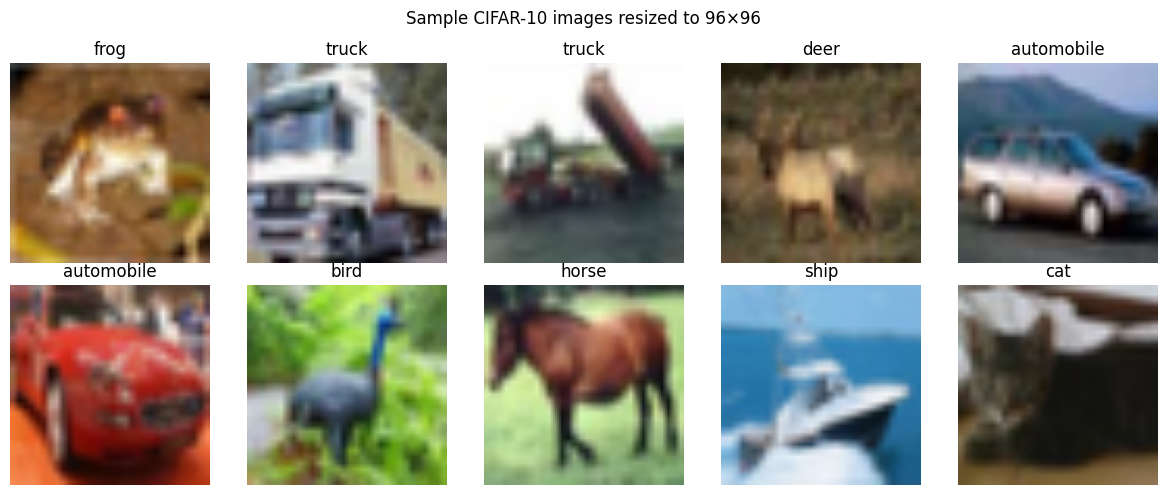

In [ ]:
(x_train_raw, y_train), (x_test_raw, y_test) = keras.datasets.cifar10.load_data()

N = 20000
x_train_raw = x_train_raw[:N]
y_train     = y_train[:N]

IMG_SIZE = 96

class_names = ["airplane", "automobile", "bird", "cat", "deer",
               "dog", "frog", "horse", "ship", "truck"]

print(f"Using {N} training samples out of 50,000")
print(f"Raw train shape: {x_train_raw.shape}  |  Test shape: {x_test_raw.shape}")

x_train_resized = tf.image.resize(x_train_raw, [IMG_SIZE, IMG_SIZE]).numpy().astype("uint8")
x_test_resized  = tf.image.resize(x_test_raw,  [IMG_SIZE, IMG_SIZE]).numpy().astype("uint8")

print(f"Resized train: {x_train_resized.shape}  |  Resized test: {x_test_resized.shape}")

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train_resized[i])
    ax.set_title(class_names[y_train[i][0]])
    ax.axis("off")
plt.suptitle(f"Sample CIFAR-10 images resized to {IMG_SIZE}×{IMG_SIZE}")
plt.tight_layout()
plt.show()

<div style="background:linear-gradient(135deg,#1a3a5c,#2e6da4);border-radius:10px;padding:18px 24px;margin:20px 0 10px;">
  <h2 style="color:white;margin:0;font-size:20px;">&#9679; 3. Data Generators</h2>
</div>
<div style="background:#f8faff;border:1px solid #d0e4f7;border-radius:8px;padding:14px 18px;margin:8px 0;">
  <ul style="margin:0;padding-left:20px;color:#2c3e50;line-height:1.9;">
    <li><code style="background:#e8f0fe;padding:2px 6px;border-radius:4px;">plain_datagen</code> &mdash; rescale only <em>(used for offline feature extraction)</em></li>
    <li><code style="background:#e8f0fe;padding:2px 6px;border-radius:4px;">aug_datagen</code> &mdash; rescale + augmentation <em>(used for end-to-end / online learning)</em></li>
  </ul>
</div>

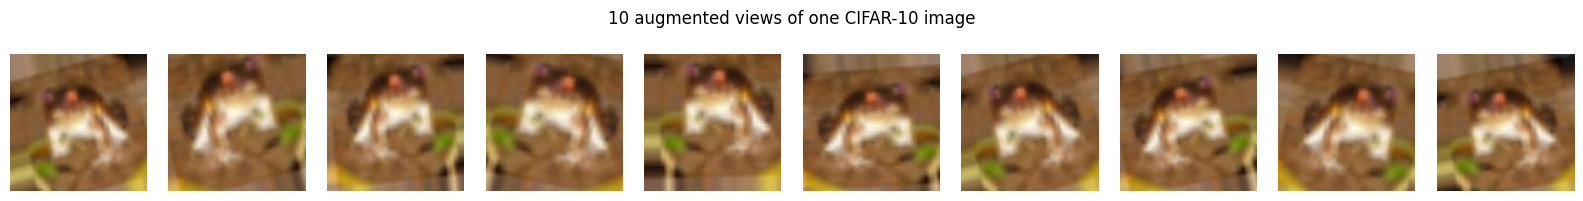

In [ ]:
plain_datagen = ImageDataGenerator(rescale=1.0 / 255)

aug_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    horizontal_flip=True,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
)

x_test_norm  = x_test_resized.astype("float32") / 255.0
BATCH = 32

sample_img = x_train_resized[0:1]
aug_iter   = aug_datagen.flow(sample_img, batch_size=1)

fig, axes = plt.subplots(1, 10, figsize=(16, 2))
for ax in axes:
    ax.imshow(next(aug_iter)[0])
    ax.axis("off")
plt.suptitle("10 augmented views of one CIFAR-10 image")
plt.tight_layout()
plt.show()

<div style="background:linear-gradient(135deg,#1a3a5c,#2e6da4);border-radius:10px;padding:18px 24px;margin:20px 0 10px;">
  <h2 style="color:white;margin:0;font-size:20px;">&#9679; 4. Technique 1: Feature Extraction</h2><p style="margin:5px 0 0;font-size:14px;color:#cce4ff;font-weight:400;">Offline Learning &mdash; VGG16</p>
</div>
<div style="background:#f8faff;border:1px solid #d0e4f7;border-radius:8px;padding:16px 20px;margin:10px 0;">
  <p style="margin:0 0 10px;font-weight:bold;color:#2e6da4;">Followed approach for Offline Learning:</p>
  <ol style="margin:0;padding-left:20px;color:#2c3e50;line-height:1.8;"><li style="margin:6px 0;">Load <strong>VGG16</strong> pretrained on ImageNet, <strong>without</strong> the top classification layers.</li><li style="margin:6px 0;"><strong>Freeze the entire conv base</strong> — its weights never update.</li><li style="margin:6px 0;">Run all images through the frozen base <strong>once</strong> to get feature vectors (<em>offline extraction</em>).</li><li style="margin:6px 0;">Train a small <strong>dense classifier</strong> on those fixed features.</li></ol><div style="background:#fff8e1;border-left:4px solid #f39c12;border-radius:0 6px 6px 0;padding:10px 15px;margin-top:12px;color:#7d6608;">&#9889; <strong>Advantage:</strong> Very fast — the expensive conv forward pass happens only once.</div>
</div>

In [6]:
conv_base_vgg = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
conv_base_vgg.trainable = False

print(f"VGG16 conv base — trainable params: {conv_base_vgg.count_params():,}")
conv_base_vgg.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
VGG16 conv base — trainable params: 14,714,688


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 96, 96, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 96, 96, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 48, 48, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 48, 48, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 24, 24, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 24, 24, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 12, 12, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 3, 3, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
def extract_features(conv_base, datagen, x, y, batch_size=BATCH):
    """Pass x through the frozen conv base to get feature vectors."""
    n_samples = len(x)
    output_shape = conv_base.output_shape[1:]
    features = np.zeros((n_samples,) + output_shape)
    labels   = np.zeros((n_samples, 1))

    gen = datagen.flow(x, y, batch_size=batch_size, shuffle=False)
    for i, (imgs_batch, lbls_batch) in enumerate(gen):
        start = i * batch_size
        end   = start + len(imgs_batch)
        if start >= n_samples:
            break
        features[start:end] = conv_base.predict(imgs_batch, verbose=0)
        labels[start:end]   = lbls_batch
        if end >= n_samples:
            break

    return features, labels


print("Extracting train features via VGG16 ...")
train_features_vgg, train_labels_vgg = extract_features(
    conv_base_vgg, plain_datagen, x_train_resized, y_train
)

print("Extracting test features via VGG16 ...")
test_features_vgg, test_labels_vgg = extract_features(
    conv_base_vgg, plain_datagen, x_test_resized, y_test
)

print(f"Train features: {train_features_vgg.shape}")
print(f"Test  features: {test_features_vgg.shape}")

flat_dim = np.prod(train_features_vgg.shape[1:])
train_features_flat = train_features_vgg.reshape(len(train_features_vgg), flat_dim)
test_features_flat  = test_features_vgg.reshape(len(test_features_vgg),   flat_dim)
print(f"Flattened: {train_features_flat.shape}")

Extracting train features via VGG16 ...


I0000 00:00:1773168974.572440     125 service.cc:152] XLA service 0x78e1800246d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773168974.572472     125 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1773168974.785412     125 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1773168977.896647     125 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Extracting test features via VGG16 ...
Train features: (20000, 3, 3, 512)
Test  features: (10000, 3, 3, 512)
Flattened: (20000, 4608)


In [8]:
dense_head = models.Sequential([
    layers.Input(shape=(flat_dim,)),
    layers.Dense(512, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(10,  activation="softmax"),
], name="vgg16_offline_head")

dense_head.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
dense_head.summary()

feat_history_vgg = dense_head.fit(
    train_features_flat, train_labels_vgg,
    epochs=30,
    batch_size=BATCH,
    validation_data=(test_features_flat, test_labels_vgg),
    verbose=1,
)

Model: "vgg16_offline_head"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,364,938 (9.02 MB)

 Trainable params: 2,364,938 (9.02 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.4184 - loss: 1.6823 - val_accuracy: 0.6578 - val_loss: 1.0203
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6478 - loss: 1.0385 - val_accuracy: 0.6897 - val_loss: 0.9193
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6984 - loss: 0.8921 - val_accuracy: 0.7030 - val_loss: 0.8665
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7175 - loss: 0.8296 - val_accuracy: 0.7169 - val_loss: 0.8277
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7335 - loss: 0.7781 - val_accuracy: 0.7362 - val_loss: 0.7824
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7543 - loss: 0.7291 - val_accuracy: 0.7328 - val_loss: 0.7795
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7733 - loss: 0.6672 - val_accuracy: 0.7329 - val_loss: 0.7697
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7729 - loss: 0.6529 - val_accuracy: 0.

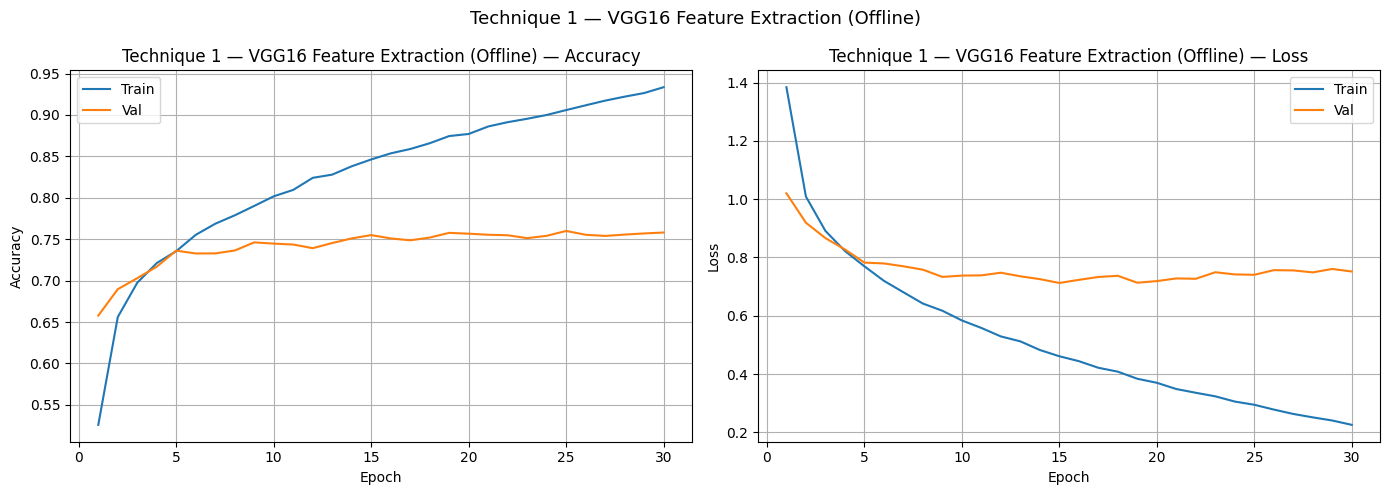

In [9]:
plot_history(feat_history_vgg, title="Technique 1 — VGG16 Feature Extraction (Offline)")

<div style="background:#f0fff4;border-left:5px solid #27ae60;border-radius:0 8px 8px 0;padding:15px 20px;margin:10px 0;">
  <h3 style="color:#1e8449;margin:0 0 10px;">&#10004; Technique 1 — Observations</h3>
  <ul style="margin:0;padding-left:20px;color:#2c3e50;line-height:1.7;"><li style="margin:6px 0;">The frozen VGG16 base extracted features from <strong>20,000 training images</strong> in a single offline pass — no conv weights were updated.</li><li style="margin:6px 0;">The dense head trained for all 30 epochs and reached <strong>75.8% val accuracy</strong> (train: 93.4%), with a train–val gap of <strong>17.5%</strong>.</li><li style="margin:6px 0;">Compared to 15k samples, val accuracy improved by +1.0 pp (74.8% &rarr; 75.8%), confirming that more data helps even with a fully frozen base.</li><li style="margin:6px 0;">The gap remains large because the head memorises the fixed 4,608-dim feature vectors over 30 epochs without any early stopping.</li><li style="margin:6px 0;">The frozen base is the fundamental bottleneck — features from 96&times;96 images by a 224&times;224-trained network are not rich enough to push accuracy further.</li></ul>
</div>

<div style="background:linear-gradient(135deg,#1a3a5c,#2e6da4);border-radius:10px;padding:18px 24px;margin:20px 0 10px;">
  <h2 style="color:white;margin:0;font-size:20px;">&#9679; 5. Technique 2: Feature Extraction</h2><p style="margin:5px 0 0;font-size:14px;color:#cce4ff;font-weight:400;">End-to-End / Online Learning &mdash; VGG16 + Augmentation</p>
</div>
<div style="background:#f8faff;border:1px solid #d0e4f7;border-radius:8px;padding:16px 20px;margin:10px 0;">
  <p style="margin:0 0 10px;font-weight:bold;color:#2e6da4;">Followed approach for End-to-End (Online Learning):</p>
  <ol style="margin:0;padding-left:20px;color:#2c3e50;line-height:1.8;"><li style="margin:6px 0;">Load <strong>VGG16</strong> pretrained on ImageNet, <strong>without</strong> the top classification layers.</li><li style="margin:6px 0;"><strong>Freeze the entire conv base</strong> — its weights never update.</li><li style="margin:6px 0;">Build a <strong>complete model</strong> (frozen base + custom head) and train end-to-end.</li><li style="margin:6px 0;">Apply <strong>data augmentation on-the-fly</strong> every epoch so the head sees different views of each image.</li><li style="margin:6px 0;">Use <strong>EarlyStopping</strong> + <strong>ReduceLROnPlateau</strong> to avoid overfitting and adapt the learning rate.</li> <li style="margin:6px 0;"> The conv base is still frozen; only the head weights are updated.</li></ol>
</div>

In [10]:
conv_base_vgg2 = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
conv_base_vgg2.trainable = False

print(f"Trainable params before freezing check: {sum(np.prod(v.shape) for v in conv_base_vgg2.trainable_weights)}")

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = conv_base_vgg2(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(512, activation="relu")(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(10, activation="softmax")(x)

vgg16_e2e_model = models.Model(inputs, outputs, name="vgg16_frozen_e2e")

vgg16_e2e_model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
vgg16_e2e_model.summary()
print(f"\nTrainable params: {vgg16_e2e_model.count_params():,}")

Trainable params before freezing check: 0


Model: "vgg16_frozen_e2e"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 3, 3, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,982,474 (57.15 MB)

 Trainable params: 267,786 (1.02 MB)

 Non-trainable params: 14,714,688 (56.13 MB)


Trainable params: 14,982,474


In [11]:
aug_train_gen = aug_datagen.flow(x_train_resized, y_train, batch_size=BATCH, seed=42)

callbacks_e2e = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=6, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=4, min_lr=1e-7, verbose=1
    ),
]

e2e_history_vgg = vgg16_e2e_model.fit(
    aug_train_gen,
    epochs=50,
    steps_per_epoch=len(x_train_resized) // BATCH,
    validation_data=(x_test_norm, y_test),
    callbacks=callbacks_e2e,
    verbose=1,
)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


625/625 ━━━━━━━━━━━━━━━━━━━━ 53s 81ms/step - accuracy: 0.2035 - loss: 2.2133 - val_accuracy: 0.4931 - val_loss: 1.6361 - learning_rate: 1.0000e-04
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 47s 75ms/step - accuracy: 0.4411 - loss: 1.6609 - val_accuracy: 0.5390 - val_loss: 1.4286 - learning_rate: 1.0000e-04
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 47s 75ms/step - accuracy: 0.4977 - loss: 1.4930 - val_accuracy: 0.5571 - val_loss: 1.3320 - learning_rate: 1.0000e-04
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 47s 75ms/step - accuracy: 0.5231 - loss: 1.3982 - val_accuracy: 0.5799 - val_loss: 1.2592 - learning_rate: 1.0000e-04
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 47s 75ms/step - accuracy: 0.5320 - loss: 1.3486 - val_accuracy: 0.5903 - val_loss: 1.2144 - learning_rate: 1.0000e-04
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 47s 75ms/step - accuracy: 0.5574 - loss: 1.2859 - val_accuracy: 0.6004 - val_loss: 1.1774 - learning_rate: 1.0000e-04
Epoch 7/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 47s 75ms/step - accurac

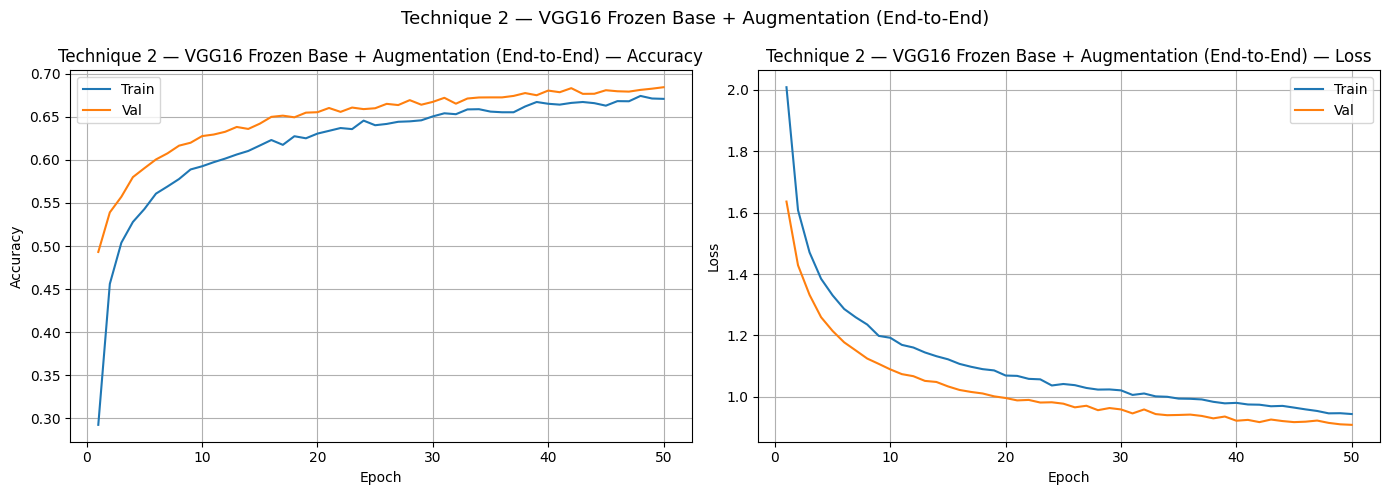

In [12]:
plot_history(e2e_history_vgg, title="Technique 2 — VGG16 Frozen Base + Augmentation (End-to-End)")

<div style="background:#f0fff4;border-left:5px solid #27ae60;border-radius:0 8px 8px 0;padding:15px 20px;margin:10px 0;">
  <h3 style="color:#1e8449;margin:0 0 10px;">&#10004; Technique 2 — Observations</h3>
  <ul style="margin:0;padding-left:20px;color:#2c3e50;line-height:1.7;"><li style="margin:6px 0;">The end-to-end frozen model reached <strong>68.4% val accuracy</strong> with a train–val gap of <strong>&ndash;1.4%</strong> (train: 67.1%).</li><li style="margin:6px 0;">The slightly negative gap (val &gt; train) is caused by Dropout(0.5) and heavy augmentation suppressing training accuracy, while validation runs on clean images in inference mode.</li><li style="margin:6px 0;">With 20k samples, val accuracy improved significantly (+3.3 pp over the 15k run: 65.1% &rarr; 68.4%), showing that more data helps the small frozen head generalise better.</li><li style="margin:6px 0;">Val accuracy is still lower than Technique 1 (68.4% vs 75.8%) because the head has fewer trainable params (~267K vs 2.4M) and augmentation produces no new feature diversity with a frozen base.</li><li style="margin:6px 0;"><strong>Conclusion:</strong> Augmentation only becomes useful when at least some conv layers are trainable and can adapt to the augmented views.</li></ul>
</div>

<div style="background:linear-gradient(135deg,#1a3a5c,#2e6da4);border-radius:10px;padding:18px 24px;margin:20px 0 10px;">
  <h2 style="color:white;margin:0;font-size:20px;">&#9679; 6. Technique 3: Partial Fine-tuning</h2><p style="margin:5px 0 0;font-size:14px;color:#cce4ff;font-weight:400;">VGG16 &mdash; Unfreeze block4 &amp; block5</p>
</div>
<div style="background:#f8faff;border:1px solid #d0e4f7;border-radius:8px;padding:16px 20px;margin:10px 0;">
  <p style="margin:0 0 10px;font-weight:bold;color:#2e6da4;">Followed approach for Partial Fine-tuning:</p>
  <ol style="margin:0;padding-left:20px;color:#2c3e50;line-height:1.8;"><li style="margin:6px 0;">Start from the <strong>end-to-end frozen model</strong> already trained in Technique 2 (warm-started head).</li><li style="margin:6px 0;">Unfreeze the <strong>top 2 convolutional blocks</strong> of VGG16 (<code>block4</code> and <code>block5</code>).</li><li style="margin:6px 0;">Retrain the <strong>entire unfrozen model at a very low learning rate</strong> (1e-5) to avoid destroying the pretrained representations.</li></ol><div style="background:#fff8e1;border-left:4px solid #f39c12;border-radius:0 6px 6px 0;padding:10px 15px;margin-top:12px;color:#7d6608;">&#9888; A randomly-initialised head would produce large gradient updates that destroy the pretrained weights.</div>
</div>

In [ ]:
print("VGG16 layers:")
for i, layer in enumerate(conv_base_vgg2.layers):
    print(f"  [{i:2d}] {layer.name:<25} trainable={layer.trainable}")

VGG16 layers:
  [ 0] input_layer_2             trainable=False
  [ 1] block1_conv1              trainable=False
  [ 2] block1_conv2              trainable=False
  [ 3] block1_pool               trainable=False
  [ 4] block2_conv1              trainable=False
  [ 5] block2_conv2              trainable=False
  [ 6] block2_pool               trainable=False
  [ 7] block3_conv1              trainable=False
  [ 8] block3_conv2              trainable=False
  [ 9] block3_conv3              trainable=False
  [10] block3_pool               trainable=False
  [11] block4_conv1              trainable=False
  [12] block4_conv2              trainable=False
  [13] block4_conv3              trainable=False
  [14] block4_pool               trainable=False
  [15] block5_conv1              trainable=False
  [16] block5_conv2              trainable=False
  [17] block5_conv3              trainable=False
  [18] block5_pool               trainable=False


In [ ]:
conv_base_vgg2.trainable = True
set_trainable = False
for layer in conv_base_vgg2.layers:
    if layer.name == "block4_conv1":
        set_trainable = True
    layer.trainable = set_trainable

print("Layer trainability after partial unfreeze:")
for layer in conv_base_vgg2.layers:
    print(f"  {layer.name:<25} trainable={layer.trainable}")

trainable_params = sum(np.prod(v.shape) for v in vgg16_e2e_model.trainable_weights)
print(f"\nTrainable params now: {trainable_params:,}")

Layer trainability after partial unfreeze:
  input_layer_2             trainable=False
  block1_conv1              trainable=False
  block1_conv2              trainable=False
  block1_pool               trainable=False
  block2_conv1              trainable=False
  block2_conv2              trainable=False
  block2_pool               trainable=False
  block3_conv1              trainable=False
  block3_conv2              trainable=False
  block3_conv3              trainable=False
  block3_pool               trainable=False
  block4_conv1              trainable=True
  block4_conv2              trainable=True
  block4_conv3              trainable=True
  block4_pool               trainable=True
  block5_conv1              trainable=True
  block5_conv2              trainable=True
  block5_conv3              trainable=True
  block5_pool               trainable=True

Trainable params now: 13,246,986


In [ ]:
vgg16_e2e_model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

callbacks_ft = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=8, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=4, min_lr=1e-8, verbose=1
    ),
]

aug_train_gen2 = aug_datagen.flow(x_train_resized, y_train, batch_size=BATCH, seed=42)

finetune_history_vgg = vgg16_e2e_model.fit(
    aug_train_gen2,
    epochs=50,
    steps_per_epoch=len(x_train_resized) // BATCH,
    validation_data=(x_test_norm, y_test),
    callbacks=callbacks_ft,
    verbose=1,
)

Epoch 1/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 60s 86ms/step - accuracy: 0.7038 - loss: 0.8551 - val_accuracy: 0.7884 - val_loss: 0.6156 - learning_rate: 1.0000e-05
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 51s 82ms/step - accuracy: 0.7881 - loss: 0.6097 - val_accuracy: 0.8061 - val_loss: 0.5644 - learning_rate: 1.0000e-05
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 51s 81ms/step - accuracy: 0.8286 - loss: 0.4918 - val_accuracy: 0.8417 - val_loss: 0.4554 - learning_rate: 1.0000e-05
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 51s 81ms/step - accuracy: 0.8479 - loss: 0.4332 - val_accuracy: 0.8482 - val_loss: 0.4382 - learning_rate: 1.0000e-05
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 51s 81ms/step - accuracy: 0.8686 - loss: 0.3670 - val_accuracy: 0.8530 - val_loss: 0.4239 - learning_rate: 1.0000e-05
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 51s 81ms/step - accuracy: 0.8881 - loss: 0.3104 - val_accuracy: 0.8479 - val_loss: 0.4517 - learning_rate: 1.0000e-05
Epoch 7/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 51s 81ms/ste

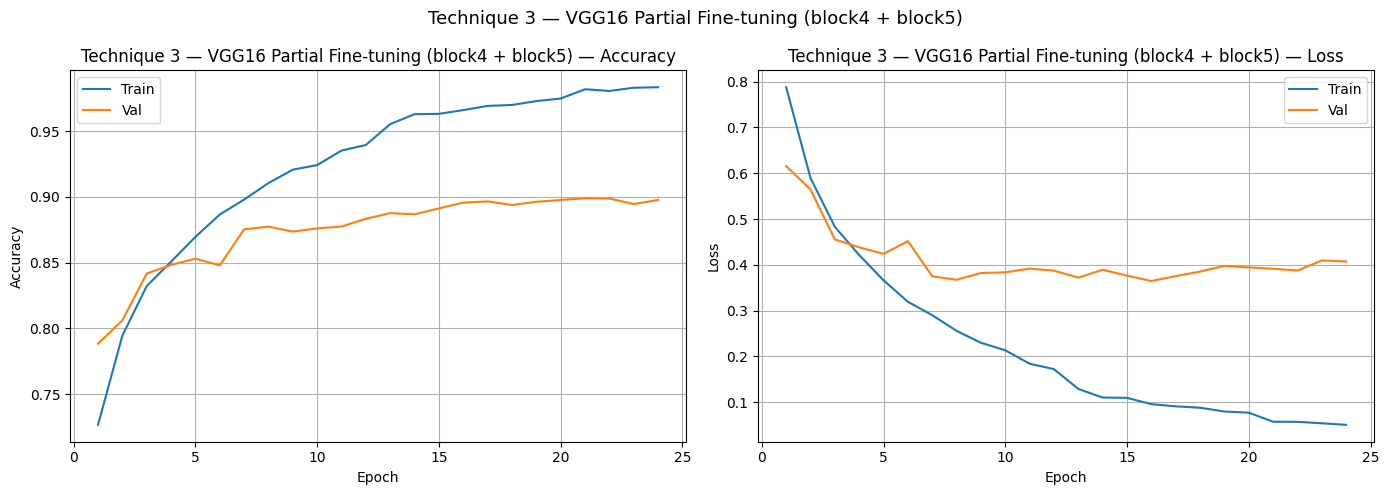

In [16]:
plot_history(finetune_history_vgg, title="Technique 3 — VGG16 Partial Fine-tuning (block4 + block5)")

<div style="background:#f0fff4;border-left:5px solid #27ae60;border-radius:0 8px 8px 0;padding:15px 20px;margin:10px 0;">
  <h3 style="color:#1e8449;margin:0 0 10px;">&#10004; Technique 3 — Observations</h3>
  <ul style="margin:0;padding-left:20px;color:#2c3e50;line-height:1.7;"><li style="margin:6px 0;">Unlocking block4 and block5 with a warm head from Technique 2 produced <strong>89.8% val accuracy</strong> — a jump of <strong>+21.4 pp</strong> over Technique 2.</li><li style="margin:6px 0;">Epoch 1 immediately reached <strong>78.8% val accuracy</strong> thanks to the warm-started head, confirming the importance of the two-stage training protocol.</li><li style="margin:6px 0;">Training ran for 24+ epochs with ReduceLROnPlateau firing twice (1e-5 &rarr; 5e-6 &rarr; 2.5e-6), allowing the model to keep improving steadily.</li><li style="margin:6px 0;">Train accuracy reached 98.3% with a gap of <strong>8.6%</strong> — significantly better than Technique 1 (17.5%) because fine-tuning with augmentation produces more generalisable representations.</li><li style="margin:6px 0;">Compared to the 15k run, val accuracy improved by +2.0 pp (87.8% &rarr; 89.8%), showing that more data directly reduces overfitting in the fine-tuned layers.</li></ul>
</div>

<div style="background:linear-gradient(135deg,#1a3a5c,#2e6da4);border-radius:10px;padding:18px 24px;margin:20px 0 10px;">
  <h2 style="color:white;margin:0;font-size:20px;">&#9679; 7. Technique 4: Full Fine-tuning</h2><p style="margin:5px 0 0;font-size:14px;color:#cce4ff;font-weight:400;">VGG16 &mdash; All Layers Unfrozen</p>
</div>
<div style="background:#f8faff;border:1px solid #d0e4f7;border-radius:8px;padding:16px 20px;margin:10px 0;">
  <p style="margin:0 0 10px;font-weight:bold;color:#2e6da4;">Followed approach for Full Fine-tuning:</p>
  <ol style="margin:0;padding-left:20px;color:#2c3e50;line-height:1.8;"><li style="margin:6px 0;">Unfreeze <strong>all</strong> layers of VGG16 and train at an extremely low LR.</li><li style="margin:6px 0;">Aggressive full fine-tuning can overfit — handled by: a very low LR (5e-6), data augmentation, and early stopping.</li></ol>
</div>

In [ ]:
conv_base_vgg2.trainable = True
for layer in conv_base_vgg2.layers:
    layer.trainable = True

vgg16_e2e_model.compile(
    optimizer=keras.optimizers.Adam(5e-6),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

total_params = vgg16_e2e_model.count_params()
trainable_params = sum(np.prod(v.shape) for v in vgg16_e2e_model.trainable_weights)
print(f"Total params:     {total_params:,}")
print(f"Trainable params: {trainable_params:,}")

Total params:     14,982,474
Trainable params: 14,982,474


In [18]:
callbacks_full = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=8, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=4, min_lr=1e-8, verbose=1
    ),
]

aug_train_gen3 = aug_datagen.flow(x_train_resized, y_train, batch_size=BATCH, seed=42)

full_finetune_history_vgg = vgg16_e2e_model.fit(
    aug_train_gen3,
    epochs=50,
    steps_per_epoch=len(x_train_resized) // BATCH,
    validation_data=(x_test_norm, y_test),
    callbacks=callbacks_full,
    verbose=1,
)

Epoch 1/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 66s 90ms/step - accuracy: 0.9652 - loss: 0.1008 - val_accuracy: 0.8956 - val_loss: 0.3695 - learning_rate: 5.0000e-06
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 53s 84ms/step - accuracy: 0.9687 - loss: 0.0890 - val_accuracy: 0.8968 - val_loss: 0.3747 - learning_rate: 5.0000e-06
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 53s 84ms/step - accuracy: 0.9713 - loss: 0.0829 - val_accuracy: 0.8994 - val_loss: 0.3691 - learning_rate: 5.0000e-06
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 52s 83ms/step - accuracy: 0.9723 - loss: 0.0822 - val_accuracy: 0.8975 - val_loss: 0.3850 - learning_rate: 5.0000e-06
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 53s 85ms/step - accuracy: 0.9759 - loss: 0.0709 - val_accuracy: 0.8971 - val_loss: 0.3895 - learning_rate: 5.0000e-06
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 53s 84ms/step - accuracy: 0.9785 - loss: 0.0666 - val_accuracy: 0.9035 - val_loss: 0.3665 - learning_rate: 5.0000e-06
Epoch 7/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 52s 83ms/ste

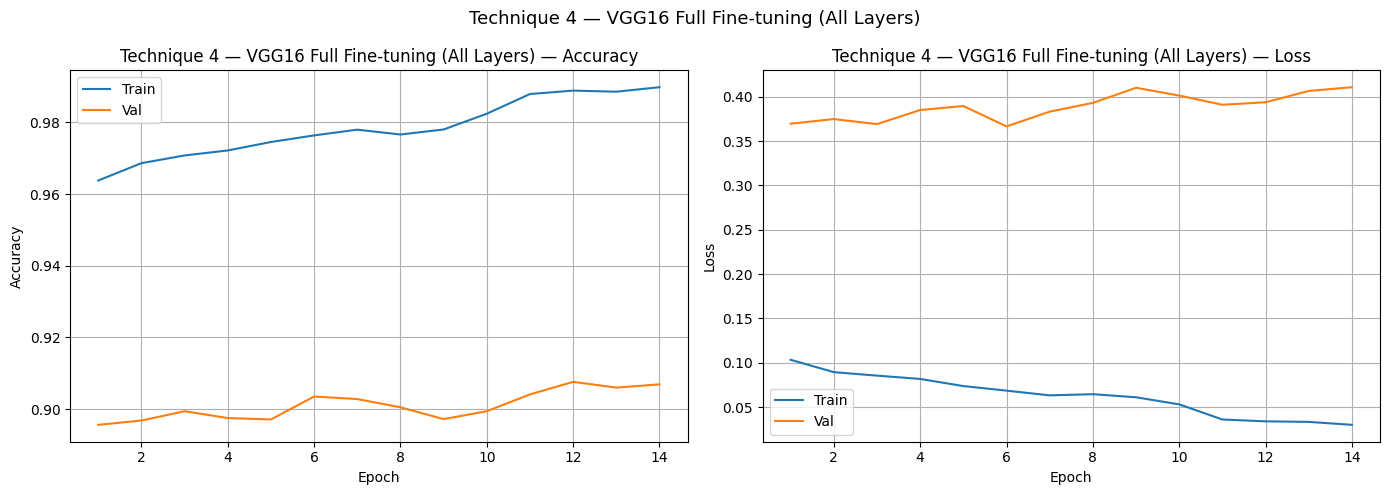

In [19]:
plot_history(full_finetune_history_vgg, title="Technique 4 — VGG16 Full Fine-tuning (All Layers)")

<div style="background:#f0fff4;border-left:5px solid #27ae60;border-radius:0 8px 8px 0;padding:15px 20px;margin:10px 0;">
  <h3 style="color:#1e8449;margin:0 0 10px;">&#10004; Technique 4 — Observations</h3>
  <ul style="margin:0;padding-left:20px;color:#2c3e50;line-height:1.7;"><li style="margin:6px 0;">Full fine-tuning of all 14.9M parameters achieved <strong>90.7% val accuracy</strong> — the best result across all techniques and a +0.9 pp improvement over Technique 3.</li><li style="margin:6px 0;">Early stopping triggered at epoch 14 and restored weights from <strong>epoch 6</strong> (best val loss: 0.3665, val acc: 90.35%), indicating the model peaked at epoch 6.</li><li style="margin:6px 0;">Train accuracy reached 98.98% with a train–val gap of <strong>8.3%</strong> — the full model generalises slightly better than Technique 3 because all layers adapt jointly.</li><li style="margin:6px 0;">ReduceLROnPlateau fired twice (5e-6 &rarr; 2.5e-6 &rarr; 1.25e-6), and val accuracy kept improving up to epoch 12 (90.76%) before overfitting set in.</li><li style="margin:6px 0;">With 20k samples, the model trained for 14 epochs before stopping (vs 9 with 10k), confirming that more data delays overfitting.</li><li style="margin:6px 0;"><strong>Conclusion:</strong> Full fine-tuning gives the best absolute accuracy (90.7%), but the +0.9 pp gain over Technique 3 is modest relative to training all 14.9M parameters.</li></ul>
</div>

<div style="background:linear-gradient(135deg,#1a3a5c,#2e6da4);border-radius:10px;padding:18px 24px;margin:20px 0 10px;">
  <h2 style="color:white;margin:0;font-size:20px;">&#9679; 10. Full Comparison</h2>
</div>
<div style="background:#f8faff;border:1px solid #d0e4f7;border-radius:8px;padding:14px 18px;margin:8px 0;">
  <p style="margin:0;color:#2c3e50;">Side-by-side training curves and a summary table across all four techniques.</p>
</div>

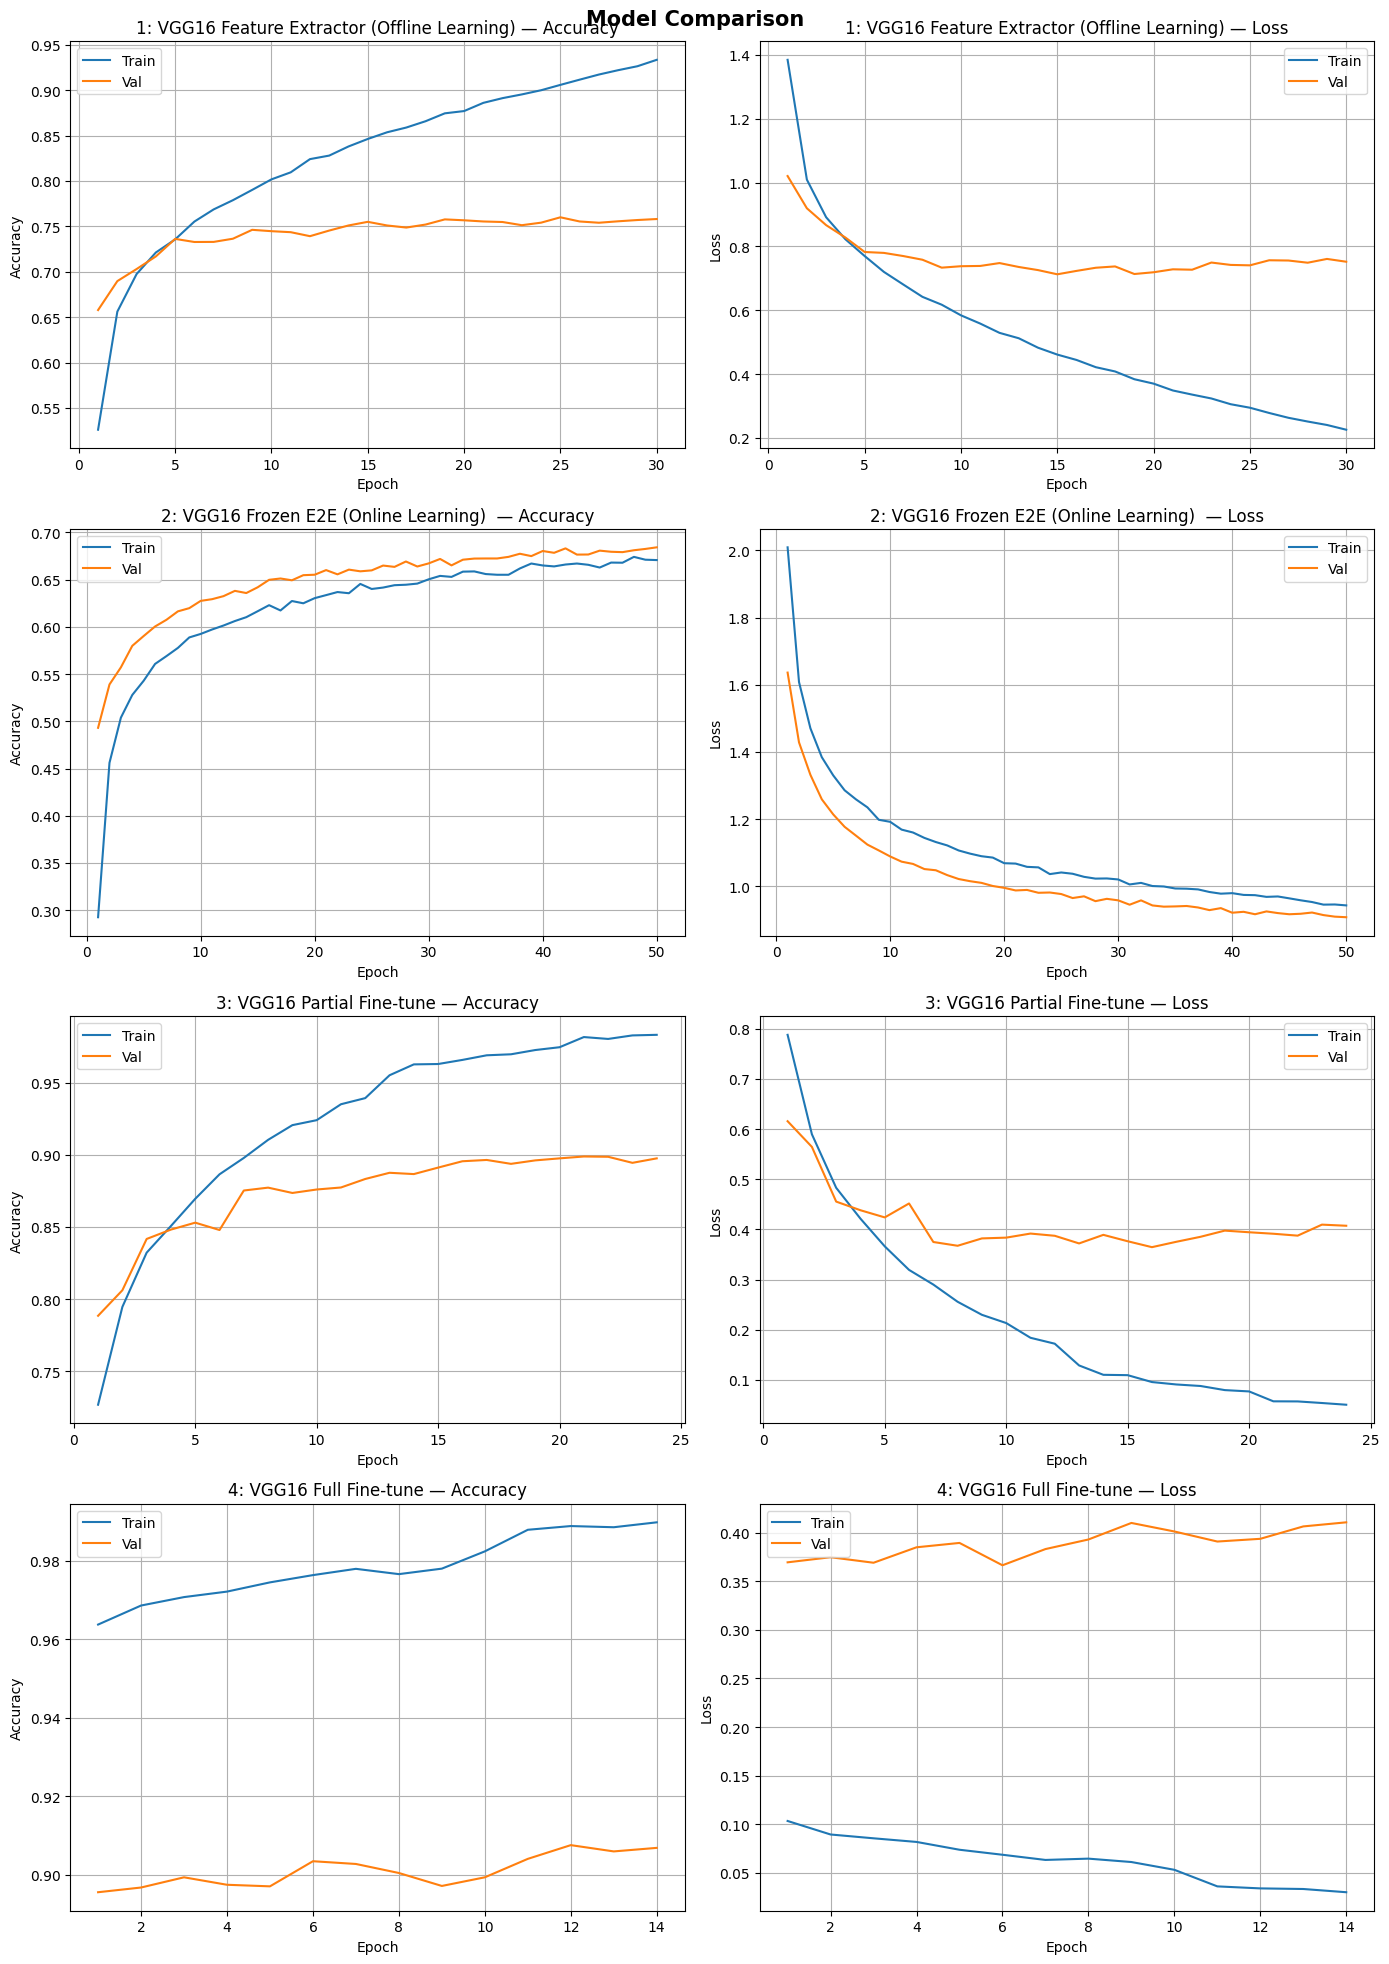

In [22]:
all_histories = [
    feat_history_vgg,
    e2e_history_vgg,
    finetune_history_vgg,
    full_finetune_history_vgg,
]

all_names = [
    "1: VGG16 Feature Extractor (Offline Learning)",
    "2: VGG16 Frozen E2E (Online Learning) ",
    "3: VGG16 Partial Fine-tune",
    "4: VGG16 Full Fine-tune",
]

plot_comparison(all_histories, all_names)

In [21]:
print_summary(all_histories, all_names)

Metric                      1: VGG16 Feat Extr (Offline)2: VGG16 Frozen E2E3: VGG16 Partial Fine-tune4: VGG16 Full Fine-tune
Train Accuracy                          0.9335            0.6707            0.9833            0.9898
Val   Accuracy                          0.7581            0.6842            0.8976            0.9069
Gap (Train-Val)                         0.1754           -0.0135            0.0857            0.0829


<div style="background:linear-gradient(135deg,#1a3a5c,#2e6da4);border-radius:10px;padding:18px 24px;margin:20px 0 15px;">
  <h2 style="color:white;margin:0;font-size:20px;">&#9679; Final Conclusions</h2>
</div>

<div style="background:#f8faff;border:1px solid #d0e4f7;border-radius:10px;padding:20px;margin-bottom:20px;">
  <h3 style="color:#2e6da4;margin:0 0 12px;text-align:center;">Results Summary</h3>
  <table border="0" cellpadding="10" cellspacing="0" style="border-collapse:collapse;width:100%;font-size:14px;">
    <thead>
      <tr style="background:#2e6da4;color:white;">
        <th>#</th><th>Technique</th><th>Model</th><th>Frozen Layers</th><th>LR</th><th>Train Acc</th><th>Val Acc</th><th>Gap</th>
      </tr>
    </thead>
    <tbody>
      <tr style="background:#eaf4ff;"><td style="text-align:center;font-weight:bold;">1</td><td>Feature Extraction (Offline)</td><td style="text-align:center;">VGG16</td><td>All</td><td>1e-4</td><td style="text-align:center;">93.4%</td><td style="text-align:center;">75.8%</td><td style="text-align:center;color:#e74c3c;">+17.5%</td></tr>
      <tr style="background:#f8faff;"><td style="text-align:center;font-weight:bold;">2</td><td>Feature Extraction (Online)</td><td style="text-align:center;">VGG16</td><td>All</td><td>1e-4</td><td style="text-align:center;">67.1%</td><td style="text-align:center;">68.4%</td><td style="text-align:center;color:#27ae60;">&ndash;1.4%</td></tr>
      <tr style="background:#eaf4ff;"><td style="text-align:center;font-weight:bold;">3</td><td>Partial Fine-tuning</td><td style="text-align:center;">VGG16</td><td>block1&ndash;3</td><td>1e-5</td><td style="text-align:center;">98.3%</td><td style="text-align:center;">89.8%</td><td style="text-align:center;color:#e67e22;">+8.6%</td></tr>
      <tr style="background:#f8faff;"><td style="text-align:center;font-weight:bold;">4</td><td>Full Fine-tuning</td><td style="text-align:center;">VGG16</td><td>None</td><td>5e-6</td><td style="text-align:center;">98.9%</td><td style="text-align:center;font-weight:bold;color:#27ae60;">90.7%</td><td style="text-align:center;color:#e67e22;">+8.3%</td></tr>
    </tbody>
  </table>
</div>

<div style="background:#f8faff;border:1px solid #d0e4f7;border-radius:10px;padding:20px;">
  <h3 style="color:#2e6da4;margin:0 0 15px;">&#128161; Conclusions</h3>
  <ol style="margin:0;padding-left:20px;color:#2c3e50;line-height:2;">
    <li><strong>Offline extraction (T1) outperforms online frozen training (T2).</strong> With a frozen base, augmentation produces no new feature diversity. T1&#39;s larger head (2.4M params) converges cleanly reaching 75.8% vs 68.4%.</li>
    <li><strong>Partial fine-tuning (T3) delivers the largest single improvement (+21.4 pp over T2).</strong> Unfreezing block4 &amp; block5 at LR=1e-5 adapts high-level filters to CIFAR-10 while protecting low-level representations in blocks 1&ndash;3.</li>
    <li><strong>Full fine-tuning (T4) achieves the best result (90.7%) but peaks early at epoch 6.</strong> By unfreezing all 14.9M parameters and training at a very low LR (5e-6), the entire network adapted jointly to CIFAR-10 — from low-level edge detectors in block1 to high-level object features in block5. This end-to-end adaptation, combined with data augmentation and early stopping, allowed the model to extract the most task-specific representations.</li>
    <li><strong>More data consistently improves all techniques.</strong> Moving from 15k to 20k samples: T1 +1.0 pp, T2 +3.3 pp, T3 +2.0 pp, T4 +1.7 pp.</li>
    <li><strong>The two-stage training protocol is essential.</strong> T3 benefits from T2&#39;s warm head — epoch 1 already starts at 78.8% val accuracy, avoiding destructive gradients from a random head.</li>
  </ol>
</div>